# Set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

In [34]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

# 0-150ms

In [71]:
# Load LFP data
start_time = 0.0
end_time = 0.12
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Fit

In [72]:
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 10
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
warp_interval=[[0, 0.15]]

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty, 
                                    warp_interval=warp_interval)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    running_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_output[i,j] = filter_list[k]
        k += 1
    
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty, 
                                    warp_interval=warp_interval)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    stationary_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_output[i,j] = filter_list[k]
        k += 1
    

6it [01:04, 10.76s/it]


## Plot filters

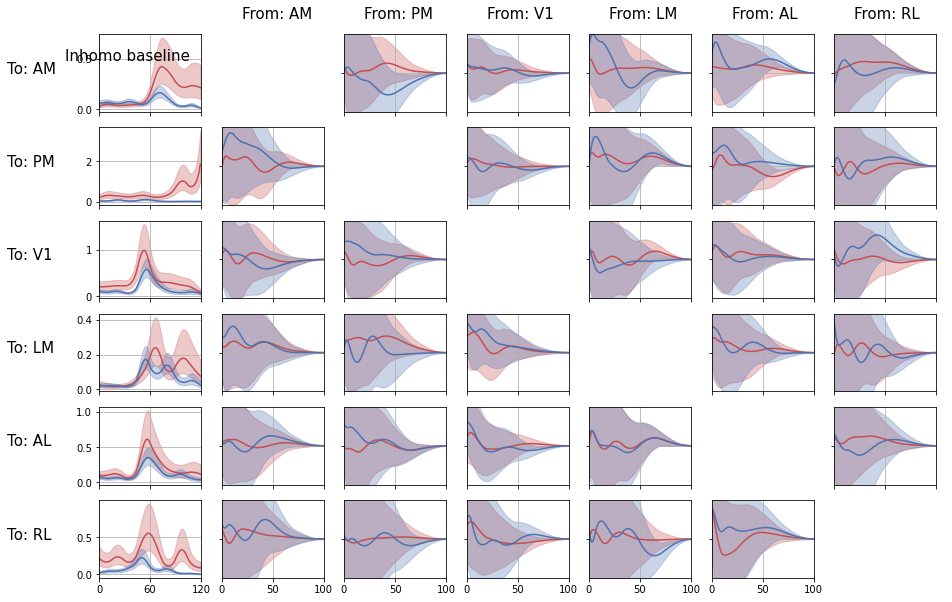

In [73]:
# use_all are all False
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15
filter_length = 100
filter_amp = 0.15
trial_length = V1.nt

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])

        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            # Correct for different number of neurons in different areas
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, (y-2*ci), (y+2*ci), color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, trial_length/2, trial_length])
            plt.xlim([0, trial_length])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-filter_amp, filter_amp])
            plt.yticks(color='w')
            plt.xticks([0, filter_length/2, filter_length])
            plt.xlim([0, filter_length])
            if i==0:
                plt.text(0.2*filter_length, 1.4*filter_amp, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-2.1*filter_length, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
#         ins = ax.inset_axes([0.6,0.6,0.4,0.4])
#         sns.kdeplot(statistics_null_filter[filter_index], linewidth=2, ax=ins, fill=True)
#         ins.axvline(statistics_filter[filter_index], linewidth=1.5, color='r')
#         ins.set_xticks([])
#         ins.set_yticks([])
#         ins.set_ylabel('')
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-4.5*filter_length, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0.2*filter_length, 3.8*filter_amp, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-0.4*filter_length, 3.2*filter_amp, f'Inhomo baseline', fontsize=fontsize)

#         if pvalue_filter[filter_index]<=0.05 and j!=-1:
#             # change yellow to ROI
#             stats_list = []
#             for ii, ROI in enumerate(ROI_filter[filter_index]):
#                 function1 = stationary_filter[filter_index][0]
#                 function2 = running_filter[filter_index][0]
#                 diff = np.abs(function1 - function2)
#                 stats_list.append( np.sum(diff[ROI]) ) 
#             temp = ROI_filter[filter_index][np.argmax(stats_list)]
#             x = np.array([temp.min(), temp.max()])
#             plt.fill_between(x, np.array([-filter_amp,-filter_amp]), np.array([filter_amp,filter_amp]), \
#                              color='yellow', alpha=.5)
#             ax.patch.set_alpha(0.3)
#             ax.set_facecolor('yellow')
            

## Plot the filter outputs

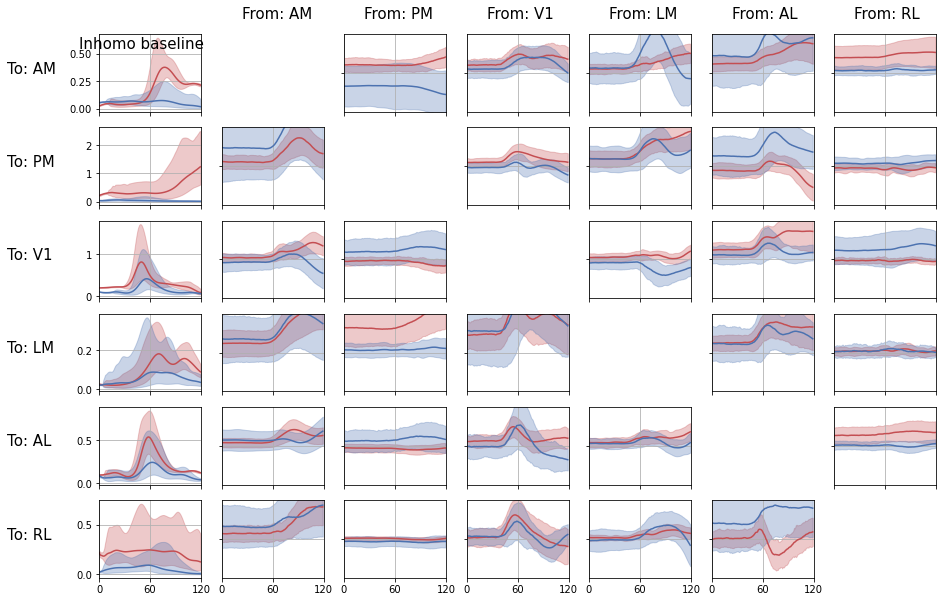

In [74]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15
filter_length = V1.nt
filter_amp = 1
trial_length = V1.nt

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_output[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_output[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, trial_length/2, trial_length])
            plt.xlim([0, trial_length])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-filter_amp, filter_amp])
            plt.yticks(color='w')
            plt.xticks([0, filter_length/2, filter_length])
            plt.xlim([0, filter_length])
            if i==0:
                plt.text(0.2*filter_length, 1.4*filter_amp, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-2.1*filter_length, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-4.5*filter_length, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0.2*filter_length, 3.8*filter_amp, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-0.2*filter_length, 0.55*filter_amp, f'Inhomo baseline', fontsize=fontsize)
        


# 200-300ms

In [64]:
# Load LFP data
start_time = 0.19
end_time = 0.31
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Fit

In [67]:
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 10
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
warp_interval=[[0.2, 0.3]]

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty, 
                                    warp_interval=warp_interval)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    running_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_output[i,j] = filter_list[k]
        k += 1
    
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty, 
                                    warp_interval=warp_interval)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    stationary_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_output[i,j] = filter_list[k]
        k += 1
    

6it [00:53,  8.96s/it]


## Plot filters

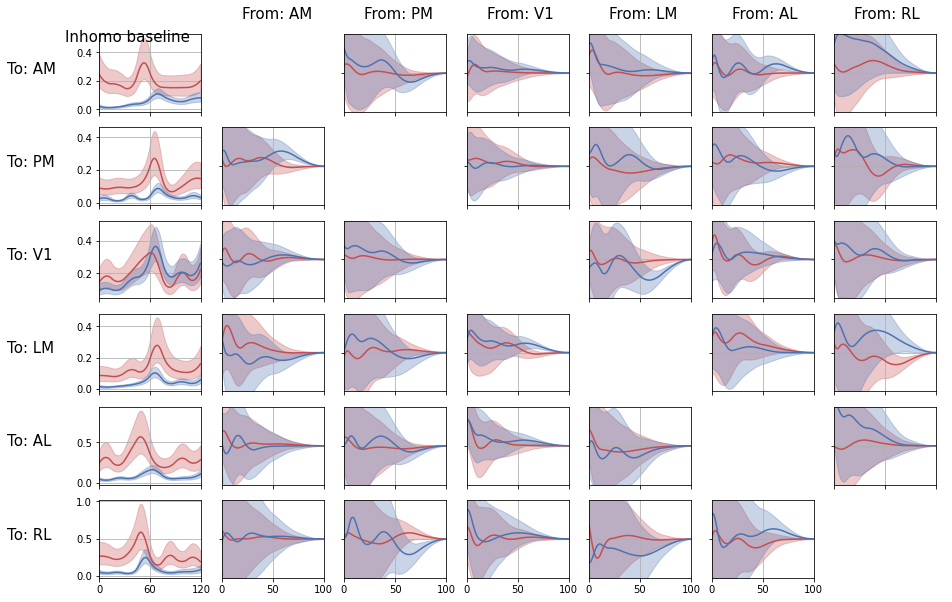

In [68]:
# use_all are all False
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15
filter_length = 100
filter_amp = 0.15
trial_length = V1.nt

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])

        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            # Correct for different number of neurons in different areas
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, (y-2*ci), (y+2*ci), color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, trial_length/2, trial_length])
            plt.xlim([0, trial_length])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-filter_amp, filter_amp])
            plt.yticks(color='w')
            plt.xticks([0, filter_length/2, filter_length])
            plt.xlim([0, filter_length])
            if i==0:
                plt.text(0.2*filter_length, 1.4*filter_amp, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-2.1*filter_length, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
#         ins = ax.inset_axes([0.6,0.6,0.4,0.4])
#         sns.kdeplot(statistics_null_filter[filter_index], linewidth=2, ax=ins, fill=True)
#         ins.axvline(statistics_filter[filter_index], linewidth=1.5, color='r')
#         ins.set_xticks([])
#         ins.set_yticks([])
#         ins.set_ylabel('')
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-4.5*filter_length, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0.2*filter_length, 3.8*filter_amp, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-0.4*filter_length, 3.2*filter_amp, f'Inhomo baseline', fontsize=fontsize)

#         if pvalue_filter[filter_index]<=0.05 and j!=-1:
#             # change yellow to ROI
#             stats_list = []
#             for ii, ROI in enumerate(ROI_filter[filter_index]):
#                 function1 = stationary_filter[filter_index][0]
#                 function2 = running_filter[filter_index][0]
#                 diff = np.abs(function1 - function2)
#                 stats_list.append( np.sum(diff[ROI]) ) 
#             temp = ROI_filter[filter_index][np.argmax(stats_list)]
#             x = np.array([temp.min(), temp.max()])
#             plt.fill_between(x, np.array([-filter_amp,-filter_amp]), np.array([filter_amp,filter_amp]), \
#                              color='yellow', alpha=.5)
#             ax.patch.set_alpha(0.3)
#             ax.set_facecolor('yellow')
            

## Plot the filter outputs

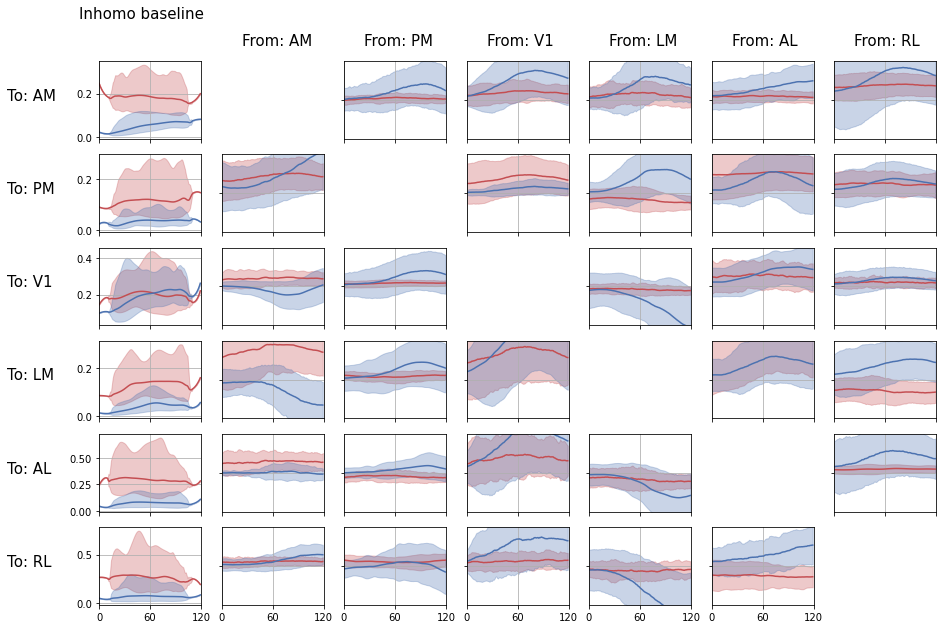

In [69]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15
filter_length = V1.nt
filter_amp = 1
trial_length = V1.nt

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_output[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_output[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, trial_length/2, trial_length])
            plt.xlim([0, trial_length])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-filter_amp, filter_amp])
            plt.yticks(color='w')
            plt.xticks([0, filter_length/2, filter_length])
            plt.xlim([0, filter_length])
            if i==0:
                plt.text(0.2*filter_length, 1.4*filter_amp, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-2.1*filter_length, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-4.5*filter_length, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0.2*filter_length, 3.8*filter_amp, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-0.2*filter_length, 0.55*filter_amp, f'Inhomo baseline', fontsize=fontsize)
        
